# Imports

In [ ]:
import os, math, time, random, warnings, zipfile, io
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             confusion_matrix, accuracy_score,
                             recall_score, precision_score,
                             ConfusionMatrixDisplay)
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


# Download and Load Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/physionet-cinc-2017-dataset")

print("Path to dataset files:", path)

100%|██████████| 95.3M/95.3M [00:06<00:00, 15.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/physionet-cinc-2017-dataset/versions/1


In [ ]:
data_dir = path +'/training2017/'

In [ ]:
ref_df = pd.read_csv(data_dir + 'REFERENCE.csv', header=None, names=['fname', 'label'])
ref_df = ref_df[ref_df['label'].isin(['N', 'A'])]  # Normal and AF only
ref_df['binary_label'] = (ref_df['label'] == 'A').astype(int)
print(f"Total Normal + AF recordings: {len(ref_df)}")
print(ref_df['label'].value_counts())

# Extract ECG signals into a list
recordings = []
labels = []
for _, row in tqdm(ref_df.iterrows(), total=len(ref_df), desc="Loading .mat files"):
    mat = sio.loadmat(data_dir + row['fname'] + '.mat')
    ecg = mat['val'].flatten().astype(np.float32)
    recordings.append(ecg)
    labels.append(row['binary_label'])

print(f"Loaded {len(recordings)} recordings")

Total Normal + AF recordings: 5788
label
N    5050
A     738
Name: count, dtype: int64


Loading .mat files:   0%|          | 0/5788 [00:00<?, ?it/s]

Loaded 5788 recordings


# Data Display

Class distribution:
0    5050
1     738
Name: count, dtype: int64


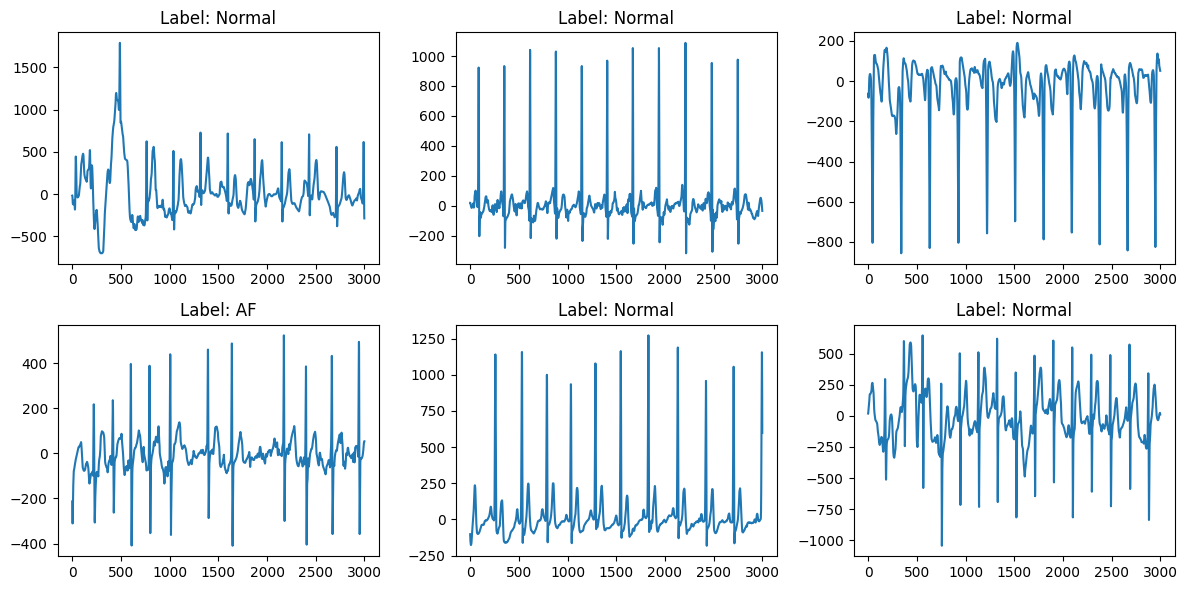

In [ ]:
print('Class distribution:')
print(pd.Series(labels).value_counts())

fig, axes = plt.subplots(2,3, figsize=(12,6))
np.random.seed(1)
for i, ax in enumerate(axes.flatten()):
    idx = np.random.choice(len(recordings))
    ax.plot(recordings[idx][:3000])
    ax.set_title(f"Label: {'AF' if labels[idx]==1 else 'Normal'}")
plt.tight_layout()
plt.show()

# Slice Recordings and Build Sequences

In [ ]:
SLICE_LEN = 75
SLICE_STRIDE = 75
T = 120

def slice_recording(ecg):
    slices = []
    for start in range(0, len(ecg)-SLICE_LEN+1, SLICE_STRIDE):
        slices.append(ecg[start:start+SLICE_LEN])
    return np.array(slices)

all_sequences, all_labels = [], []
for ecg, lbl in zip(recordings, labels):
    slices = slice_recording(ecg)
    if len(slices) < T: continue
    all_sequences.append(slices[:T])
    all_labels.append(lbl)
X_all = np.array(all_sequences, dtype=np.float32)
y_all = np.array(all_labels, dtype=np.int64)
print(f'Total sequences: {X_all.shape}, labels: {y_all.shape}')
print(f'Class balance: {np.bincount(y_all)}')

n_total = len(X_all)
train_end = int(n_total*0.7)
val_end   = int(n_total*0.85)
X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val     = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test   = X_all[val_end:], y_all[val_end:]
X_test_raw = X_test.copy()

all_train_slices = X_train.reshape(-1, SLICE_LEN)
scaler = StandardScaler().fit(all_train_slices)
def scale_sequences(X):
    orig = X.shape
    X_flat = X.reshape(-1, SLICE_LEN)
    return scaler.transform(X_flat).reshape(orig)
X_train = scale_sequences(X_train)
X_val   = scale_sequences(X_val)
X_test  = scale_sequences(X_test)

Total sequences: (5154, 120, 75), labels: (5154,)
Class balance: [4529  625]


# Phase 1 - CNN Feature Extractor

In [ ]:
FEAT_DIM = 128

class BetterSliceCNN(nn.Module):
    def __init__(self, feat_dim=128, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, 7, padding=3, stride=1)
        self.bn1   = nn.BatchNorm1d(32)
        self.res1 = self._make_res_block(32, 64, stride=2)
        self.res2 = self._make_res_block(64, 128, stride=2)
        self.res3 = self._make_res_block(128, feat_dim, stride=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(feat_dim, num_classes)

    @staticmethod
    def _make_res_block(in_ch, out_ch, stride):
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 5, stride=stride, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, 5, stride=1, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x):
        x = x.view(-1, 1, SLICE_LEN)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        feats = self.pool(x).squeeze(-1)
        logits = self.classifier(feats)
        return logits, feats

all_train_slices_flat = X_train.reshape(-1, SLICE_LEN)
train_labels_flat = np.repeat(y_train, T)
class0_idx = np.where(train_labels_flat==0)[0]
class1_idx = np.where(train_labels_flat==1)[0]
min_len = min(len(class0_idx), len(class1_idx))
sel0 = np.random.RandomState(42).choice(class0_idx, min_len, replace=False)
sel1 = np.random.RandomState(42).choice(class1_idx, min_len, replace=False)
bal_idx = np.concatenate([sel0,sel1]); np.random.shuffle(bal_idx)
train_slices_bal = all_train_slices_flat[bal_idx]
train_labels_bal = train_labels_flat[bal_idx]

train_X = torch.tensor(train_slices_bal, dtype=torch.float32)
train_Y = torch.tensor(train_labels_bal, dtype=torch.long)
phase1_loader = DataLoader(TensorDataset(train_X, train_Y), batch_size=256, shuffle=True)

cnn = BetterSliceCNN(FEAT_DIM).to(device)
opt = optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

PATIENCE1, MIN_DELTA1 = 10, 0.001
best_val_bacc, patience_counter = 0.0, 0
for epoch in range(100):
    cnn.train(); total_loss=0
    for xb, yb in phase1_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        logits, _ = cnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    val_slices = X_val.reshape(-1, SLICE_LEN)
    val_X = torch.tensor(val_slices, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = cnn(val_X)[0].argmax(1).cpu().numpy()
    val_bacc = balanced_accuracy_score(np.repeat(y_val,T), preds)
    if val_bacc - best_val_bacc > MIN_DELTA1:
        best_val_bacc = val_bacc; patience_counter = 0
        torch.save(cnn.state_dict(), 'best_cnn.pth')
    else:
        patience_counter += 1
    if (epoch+1)%5==0:
        print(f'Phase1 Epoch {epoch+1:3d}: val bacc={val_bacc:.4f} (best={best_val_bacc:.4f})')
    if patience_counter >= PATIENCE1:
        print(f'Early stopping at epoch {epoch+1}')
        break
cnn.load_state_dict(torch.load('best_cnn.pth')); cnn.eval()
print(f'Best Phase1 val bacc: {best_val_bacc:.4f}')

Phase1 Epoch   5: val bacc=0.6651 (best=0.6651)
Phase1 Epoch  10: val bacc=0.6650 (best=0.6710)
Phase1 Epoch  15: val bacc=0.6647 (best=0.6798)
Phase1 Epoch  20: val bacc=0.6770 (best=0.6798)
Early stopping at epoch 23
Best Phase1 val bacc: 0.6798


# Extract Features

In [ ]:
def extract_features(model, X_arr, batch_size=256):
    feats = []
    for i in range(0, len(X_arr), batch_size):
        xb = torch.tensor(X_arr[i:i+batch_size], dtype=torch.float32).to(device)
        with torch.no_grad():
            _, f = model(xb)
        feats.append(f.cpu().numpy())
    return np.concatenate(feats, axis=0)

train_feats = extract_features(cnn, X_train.reshape(-1,SLICE_LEN)).reshape(X_train.shape[0], T, FEAT_DIM)
val_feats   = extract_features(cnn, X_val.reshape(-1,SLICE_LEN)).reshape(X_val.shape[0], T, FEAT_DIM)
test_feats  = extract_features(cnn, X_test.reshape(-1,SLICE_LEN)).reshape(X_test.shape[0], T, FEAT_DIM)

train_set = TensorDataset(torch.tensor(train_feats, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_set   = TensorDataset(torch.tensor(val_feats, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_set  = TensorDataset(torch.tensor(test_feats, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
X_test_seq_raw = X_test_raw

# SPRT-TANDEM Integrator

In [ ]:
def B2Bsqrt(x, alpha=1.0):
    a = torch.tensor(alpha, device=x.device, dtype=x.dtype)
    return torch.sign(x)*(torch.sqrt(a+torch.abs(x))-torch.sqrt(a))

class StandardLSTM(nn.Module):
    def __init__(self, feat_dim, hidden_size, out_activation='B2Bsqrt'):
        super().__init__()
        self.feat_dim, self.hidden_size, self.out_activation = feat_dim, hidden_size, out_activation
        self.W_i = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_i = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_i = nn.Parameter(torch.Tensor(hidden_size))
        self.W_f = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_f = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_f = nn.Parameter(torch.Tensor(hidden_size))
        self.W_c = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_c = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_c = nn.Parameter(torch.Tensor(hidden_size))
        self.W_o = nn.Parameter(torch.Tensor(feat_dim, hidden_size))
        self.U_o = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_o = nn.Parameter(torch.Tensor(hidden_size))
        self.init_weights()
    def init_weights(self):
        for w in [self.W_i, self.W_f, self.W_c, self.W_o, self.U_i, self.U_f, self.U_c, self.U_o]:
            nn.init.xavier_uniform_(w)
        for b in [self.b_i, self.b_f, self.b_c, self.b_o]:
            nn.init.constant_(b,0)
    def forward(self, x):
        batch, steps, _ = x.shape
        h = torch.zeros(batch, self.hidden_size, device=x.device)
        c = torch.zeros(batch, self.hidden_size, device=x.device)
        outs = []
        for t in range(steps):
            xt = x[:,t,:]
            i_t = torch.sigmoid(xt@self.W_i + h@self.U_i + self.b_i)
            f_t = torch.sigmoid(xt@self.W_f + h@self.U_f + self.b_f)
            o_t = torch.sigmoid(xt@self.W_o + h@self.U_o + self.b_o)
            c_tilde = B2Bsqrt(xt@self.W_c + h@self.U_c + self.b_c)
            c = f_t*c + i_t*c_tilde
            h = o_t*B2Bsqrt(c) if self.out_activation=='B2Bsqrt' else o_t*torch.tanh(c)
            outs.append(h.unsqueeze(1))
        return torch.cat(outs, dim=1)

def calc_llrs(logits_concat, order_sprt, time_steps, num_classes):
    batch, eff_T, win_len, nc = logits_concat.shape
    logits1 = logits_concat.unsqueeze(-1)
    logits2 = logits_concat.unsqueeze(-2)
    llr_list = []
    if order_sprt==0:
        lr = logits1[:,:,0,:,:] - logits2[:,:,0,:,:]
        llrs = torch.cumsum(lr, dim=1)
    else:
        for t in range(time_steps):
            if t < order_sprt+1:
                lr = logits1[:,0,t,:,:] - logits2[:,0,t,:,:]
            else:
                idx = t - order_sprt
                lr1 = logits1[:,:idx,order_sprt,:,:] - logits2[:,:idx,order_sprt,:,:]
                lr1 = torch.sum(lr1, dim=1)
                if idx>1:
                    lr2 = logits1[:,1:idx,order_sprt-1,:,:] - logits2[:,1:idx,order_sprt-1,:,:]
                    lr2 = torch.sum(lr2, dim=1)
                else:
                    lr2 = torch.zeros_like(lr1)
                lr = lr1 - lr2
            llr_list.append(lr.unsqueeze(1))
        llrs = torch.cat(llr_list, dim=1)
    tri = torch.ones_like(llrs)
    llrs = llrs - 1e-12*(torch.triu(tri)-torch.tril(tri))
    return llrs

def restore_lost_significance(llrs):
    tri = torch.ones_like(llrs)
    return llrs - 1e-10*(torch.triu(tri)-torch.tril(tri))

def multiplet_ce_flat(logits_flat, labels_slice):
    logits = logits_flat.permute(1,0,2).reshape(-1, logits_flat.shape[-1])
    labels = labels_slice.repeat(logits_flat.shape[1])
    return F.cross_entropy(logits, labels)

def lsel_loss(llrs, labels):
    bs, T, nc, _ = llrs.shape
    labels_oh = F.one_hot(labels, nc).float().view(bs, 1, nc, 1)
    llrs_masked = llrs * labels_oh
    llrs_vec = torch.sum(llrs_masked, dim=2)
    llrs_flat = llrs_vec.reshape(-1, nc)
    minllr, _ = torch.min(llrs_flat, dim=1, keepdim=True)
    llrs_stable = llrs_flat - minllr
    loss = -minllr.squeeze(1) + torch.log(torch.sum(torch.exp(-llrs_stable), dim=1) + 1e-12)
    return loss.mean()

ORDER = 5
NUM_CLASSES = 2
WIDTH_LSTM = 64
DROPOUT = 0.1

class SPRTTANDEMIntegrator(nn.Module):
    def __init__(self, feat_dim, num_classes, order_sprt, hidden_size,
                 time_steps=T, dropout=DROPOUT, use_pe=True):
        super().__init__()
        self.order_sprt = order_sprt
        self.time_steps = time_steps
        self.num_classes = num_classes
        self.use_pe = use_pe
        if use_pe:
            self.pos_encoding = nn.Parameter(torch.randn(order_sprt+1, feat_dim))
        self.lstm = StandardLSTM(feat_dim, hidden_size, out_activation='B2Bsqrt')
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        bs, T_full, F = x.shape
        win_len = self.order_sprt + 1
        eff_T = T_full - self.order_sprt
        windows = []
        for i in range(eff_T):
            windows.append(x[:, i:i+win_len, :])
        x_windows = torch.stack(windows, dim=1)
        if self.use_pe:
            x_windows = x_windows + self.pos_encoding.view(1,1,win_len,F)
        x_flat = x_windows.reshape(bs*eff_T, win_len, F)
        lstm_out = self.lstm(x_flat)
        lstm_out = self.dropout(lstm_out)
        logits_flat = self.fc(lstm_out)
        logits_struct = logits_flat.view(bs, eff_T, win_len, self.num_classes)
        return logits_flat, logits_struct, (bs, eff_T)

In [ ]:
LR = 1e-4
W_MCE = 0.6
W_LSEL = 0.3
MAX_NORM = 50000.0
PATIENCE2, MIN_DELTA2 = 80, 0.001

integrator = SPRTTANDEMIntegrator(FEAT_DIM, NUM_CLASSES, ORDER, WIDTH_LSTM,
                                   time_steps=T, use_pe=True).to(device)
optimizer = optim.Adam(integrator.parameters(), lr=LR, weight_decay=0.0)

best_val_bacc, patience_cnt = 0.0, 0
for epoch in range(500):
    integrator.train()
    tot_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits_flat, logits_struct, (bs, eff_T) = integrator(xb)
        llrs = calc_llrs(logits_struct, ORDER, T, NUM_CLASSES)
        y_slice = yb.repeat(eff_T)
        mce = multiplet_ce_flat(logits_flat, y_slice)
        lsel = lsel_loss(llrs, yb)
        loss = W_MCE*mce + W_LSEL*lsel
        loss.backward()
        torch.nn.utils.clip_grad_norm_(integrator.parameters(), MAX_NORM)
        optimizer.step()
        tot_loss += loss.item()

    integrator.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb_v, yb_v in val_loader:
            xb_v, yb_v = xb_v.to(device), yb_v.to(device)
            _, logits_v, _ = integrator(xb_v)
            llrs_v = calc_llrs(logits_v, ORDER, T, NUM_CLASSES)
            lr_last = llrs_v[:,-1,1,0]
            pred = (lr_last>0).long()
            all_preds.append(pred.cpu()); all_labels.append(yb_v.cpu())
    val_bacc = balanced_accuracy_score(torch.cat(all_labels).numpy(),
                                       torch.cat(all_preds).numpy())
    if val_bacc - best_val_bacc > MIN_DELTA2:
        best_val_bacc = val_bacc; patience_cnt = 0
        torch.save(integrator.state_dict(), 'best_integrator.pth')
    else:
        patience_cnt += 1
    if (epoch+1)%20==0 or epoch==0:
        print(f'Epoch {epoch+1:3d}: loss={tot_loss/len(train_loader):.4f}, val bacc={val_bacc:.4f} (best={best_val_bacc:.4f})')
    if patience_cnt >= PATIENCE2:
        print(f'Early stopping at epoch {epoch+1}')
        break
integrator.load_state_dict(torch.load('best_integrator.pth')); integrator.eval()
print(f'Best integrator val bacc: {best_val_bacc:.4f}')

Epoch   1: loss=0.7910, val bacc=0.5281 (best=0.5281)
Epoch  20: loss=0.2714, val bacc=0.8488 (best=0.8864)
Epoch  40: loss=0.2651, val bacc=0.8537 (best=0.9119)
Epoch  60: loss=0.2630, val bacc=0.8838 (best=0.9119)
Epoch  80: loss=0.2613, val bacc=0.8425 (best=0.9119)
Epoch 100: loss=0.2604, val bacc=0.8383 (best=0.9226)
Epoch 120: loss=0.2612, val bacc=0.9067 (best=0.9226)
Epoch 140: loss=0.2604, val bacc=0.8593 (best=0.9226)
Epoch 160: loss=0.2597, val bacc=0.8642 (best=0.9226)
Early stopping at epoch 176
Best integrator val bacc: 0.9226


# Baseline - Fixed-Length LSTM

In [ ]:
class FixedLSTM(nn.Module):
    def __init__(self, feat_dim, hidden_size, num_classes, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(feat_dim, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:,-1,:])
        return self.fc(out)

baseline = FixedLSTM(FEAT_DIM, WIDTH_LSTM, NUM_CLASSES).to(device)
optim_base = optim.Adam(baseline.parameters(), lr=LR, weight_decay=0.0)
best_val_bacc_bl, patience_bl = 0.0, 0
for epoch in range(200):
    baseline.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optim_base.zero_grad()
        loss = F.cross_entropy(baseline(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(baseline.parameters(), MAX_NORM)
        optim_base.step()
    baseline.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb_v, yb_v in val_loader:
            pred = baseline(xb_v.to(device)).argmax(1).cpu()
            all_preds.append(pred); all_labels.append(yb_v)
    val_bacc = balanced_accuracy_score(torch.cat(all_labels).numpy(),
                                       torch.cat(all_preds).numpy())
    if val_bacc - best_val_bacc_bl > 0.0005:
        best_val_bacc_bl = val_bacc; patience_bl = 0
        torch.save(baseline.state_dict(), 'best_baseline.pth')
    else:
        patience_bl += 1
    if (epoch+1)%30==0:
        print(f'Baseline Epoch {epoch+1}: val bacc={val_bacc:.4f}')
    if patience_bl >= 40:
        print(f'Baseline early stopping at epoch {epoch+1}')
        break
baseline.load_state_dict(torch.load('best_baseline.pth')); baseline.eval()
print(f'Best baseline val bacc: {best_val_bacc_bl:.4f}')

Baseline Epoch 30: val bacc=0.8117
Baseline early stopping at epoch 48
Best baseline val bacc: 0.8916


# Online Inference for SPRT-TANDEM

In [ ]:
def online_inference(model, feature_extractor, scaler, X_stream, y_stream,
                     th_a1, th_a0, order=ORDER):
    model.eval(); feature_extractor.eval()
    pos_enc = model.pos_encoding.detach()
    preds, hts = [], []
    for seq_idx in range(len(X_stream)):
        buffer, total_llr, decision, stop_t = [], None, None, None
        for t in range(T):
            x_raw = X_stream[seq_idx, t]
            x_scaled = scaler.transform([x_raw])[0]
            x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                _, feat = feature_extractor(x_tensor)
            feat = feat.cpu().numpy()[0]
            buffer.append(feat)
            if len(buffer) > order+1: buffer.pop(0)
            if len(buffer) == order+1:
                buf_tensor = torch.tensor(buffer, dtype=torch.float32).unsqueeze(0).to(device)
                buf_tensor = buf_tensor + pos_enc.unsqueeze(0)
                with torch.no_grad():
                    lstm_out = model.lstm(buf_tensor)
                    logits = model.fc(lstm_out)
                if total_llr is None:
                    total_llr = logits[0,-1,1] - logits[0,-1,0]
                else:
                    lr_N1 = logits[0,-1,1] - logits[0,-1,0]
                    lr_N  = logits[0,-2,1] - logits[0,-2,0]
                    total_llr += (lr_N1 - lr_N)
                if total_llr >= th_a1:
                    decision = 1; stop_t = t+1; break
                elif total_llr <= -th_a0:
                    decision = 0; stop_t = t+1; break
        if decision is None:
            decision = 1 if total_llr>0 else 0
            stop_t = T
        preds.append(decision); hts.append(stop_t)
    return np.array(preds), np.array(hts)

# SAT Evaluation with 1000 Log-spaced Thresholds

In [ ]:
def evaluate_sprt_tandem_sat(model, loader, num_thresh=1000):
    model.eval()
    all_llrs, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        _, logits, (bs, eff_T) = model(xb)
        llrs = calc_llrs(logits, ORDER, T, NUM_CLASSES)
        all_llrs.append(llrs.cpu()); all_labels.append(yb)
    llrs_t = torch.cat(all_llrs, dim=0)
    labels_t = torch.cat(all_labels, dim=0)
    llrs_t = restore_lost_significance(llrs_t)
    n, Tclip, nc = llrs_t.shape[0], llrs_t.shape[1], llrs_t.shape[2]
    dev = llrs_t.device
    abs_vals = llrs_t.abs()
    min_abs = abs_vals[abs_vals>1e-12].min().item()
    max_abs = abs_vals.max().item()
    threshs = torch.exp(torch.linspace(math.log(min_abs), math.log(max_abs), num_thresh))
    eye = torch.eye(nc, device=dev)
    mhts, baccs = [], []
    for thr in threshs:
        thresh_mtx = thr*(1-eye).view(1,1,1,nc,nc).repeat(1,1,Tclip,1,1)
        scores_full = llrs_t.unsqueeze(0) - thresh_mtx
        scores = torch.min(scores_full, dim=-1)[0]
        preds_all = torch.sign(scores) + 1
        last_llr = llrs_t[:,-1:,:,:]
        last_scores = torch.min(last_llr, dim=-1)[0]
        preds_last = torch.sign(last_scores)+1
        preds_last = preds_last.unsqueeze(0)
        preds_trunc = torch.cat([preds_all[:,:,:-1,:], preds_last], dim=2)
        mask = torch.arange(Tclip,0,-1, dtype=torch.float32, device=dev).view(1,1,Tclip,1)
        masked = preds_trunc * mask
        hit_idx = torch.max(masked, dim=2)[0]
        _, pred_class = torch.max(hit_idx, dim=2)
        hit_time = Tclip - torch.max(hit_idx, dim=2)[0] + 1
        labels = labels_t
        mht = hit_time.float().mean().item()
        tp = ((pred_class==1)&(labels==1)).sum().item()
        tn = ((pred_class==0)&(labels==0)).sum().item()
        pos = (labels==1).sum().item()
        neg = (labels==0).sum().item()
        bacc = ((tp/pos if pos else 0) + (tn/neg if neg else 0))/2.0
        mhts.append(mht); baccs.append(bacc)
    return threshs.numpy(), np.array(mhts), np.array(baccs)

alpha, beta = 0.05, 0.01
a_wald1 = math.log((1-beta)/alpha)
a_wald0 = math.log((1-alpha)/beta)
print(f'Wald thresholds: a1={a_wald1:.3f}, a0={a_wald0:.3f}')

threshs_val, mhts_val, baccs_val = evaluate_sprt_tandem_sat(integrator, val_loader)
opt_idx = np.argmax(baccs_val)
a_opt = threshs_val[opt_idx]
print(f'Optimal threshold from validation: {a_opt:.3f}')

preds_opt, hts_opt = online_inference(integrator, cnn, scaler,
                                       X_test_seq_raw, y_test, a_opt, a_opt)
preds_wald, hts_wald = online_inference(integrator, cnn, scaler,
                                        X_test_seq_raw, y_test, a_wald1, a_wald0)

# Baseline at multiple observation lengths
def evaluate_fixed_at_length(model, feat_tensor, lengths):
    model.eval()
    results = {}
    for k in lengths:
        preds, labs = [], []
        for i in range(0, len(feat_tensor), BATCH_SIZE):
            xb = feat_tensor[i:i+BATCH_SIZE, :k, :].to(device)
            yb = torch.tensor(y_test[i:i+BATCH_SIZE]).long()
            with torch.no_grad():
                out = model(xb)
            preds.append(out.argmax(1).cpu())
            labs.append(yb)
        preds = torch.cat(preds).numpy()
        labs  = torch.cat(labs).numpy()
        results[k] = (balanced_accuracy_score(labs, preds), f1_score(labs, preds))
    return results

horizons = [20,40,60,80,100,120]
baseline_by_len = evaluate_fixed_at_length(baseline, torch.tensor(test_feats, dtype=torch.float32), horizons)

threshs_test, mhts_test, baccs_test = evaluate_sprt_tandem_sat(integrator, test_loader)

Wald thresholds: a1=2.986, a0=4.554
Optimal threshold from validation: 2.572


In [ ]:
baseline_by_len

{20: (np.float64(0.764403160367286), 0.5739910313901345),
 40: (np.float64(0.8316250266922913), 0.6374501992031872),
 60: (np.float64(0.8639333760409993), 0.6825396825396826),
 80: (np.float64(0.8674781123211617), 0.6717557251908397),
 100: (np.float64(0.8659833440102498), 0.6666666666666666),
 120: (np.float64(0.8627162075592569), 0.6666666666666666)}

# Metrics and Comparison Table

In [ ]:
def compute_metrics(y_true, y_pred, hts):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size==4 else (0,0,0,0)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    return {
        'Bal.Acc': balanced_accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Sens': sens, 'Spec': spec, 'Prec': prec,
        'Mean HT': np.mean(hts),
        'Time Saved %': (1 - np.mean(hts)/T)*100
    }

metrics_opt = compute_metrics(y_test, preds_opt, hts_opt)
metrics_wald = compute_metrics(y_test, preds_wald, hts_wald)

# Baseline full length
baseline.eval()
all_preds_base, all_labs_base = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        pred = baseline(xb.to(device)).argmax(1).cpu()
        all_preds_base.append(pred); all_labs_base.append(yb)
preds_base = torch.cat(all_preds_base).numpy()
labs_base  = torch.cat(all_labs_base).numpy()
base_bacc = balanced_accuracy_score(labs_base, preds_base)
base_f1   = f1_score(labs_base, preds_base)
base_sens = recall_score(labs_base, preds_base)
tn, fp, fn, tp = confusion_matrix(labs_base, preds_base).ravel()
base_spec = tn/(tn+fp) if (tn+fp)>0 else 0
base_prec = tp/(tp+fp) if (tp+fp)>0 else 0
metrics_base = {'Bal.Acc': base_bacc, 'F1': base_f1, 'Sens': base_sens,
                'Spec': base_spec, 'Prec': base_prec, 'Mean HT': float(T), 'Time Saved %': 0.0}

df_metrics = pd.DataFrame([metrics_opt, metrics_wald, metrics_base])
df_metrics.index = ['SPRT-TANDEM (opt)', 'SPRT-TANDEM (Wald)', 'Baseline (full 120)']
print(df_metrics.to_string(float_format='%.3f'))

                     Bal.Acc    F1  Sens  Spec  Prec  Mean HT  Time Saved %
SPRT-TANDEM (opt)      0.871 0.711 0.819 0.924 0.628   34.902        70.915
SPRT-TANDEM (Wald)     0.870 0.705 0.819 0.921 0.619   57.049        52.459
Baseline (full 120)    0.863 0.667 0.829 0.897 0.558  120.000         0.000


# Visualisations

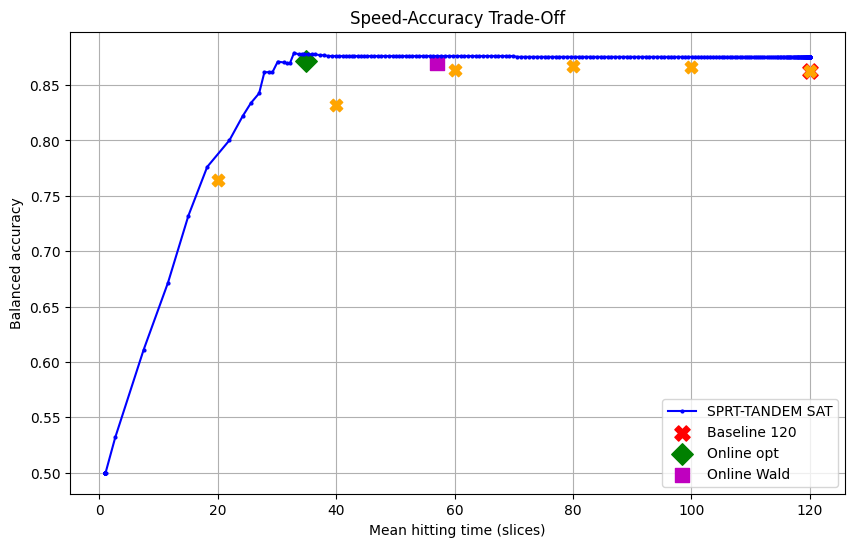

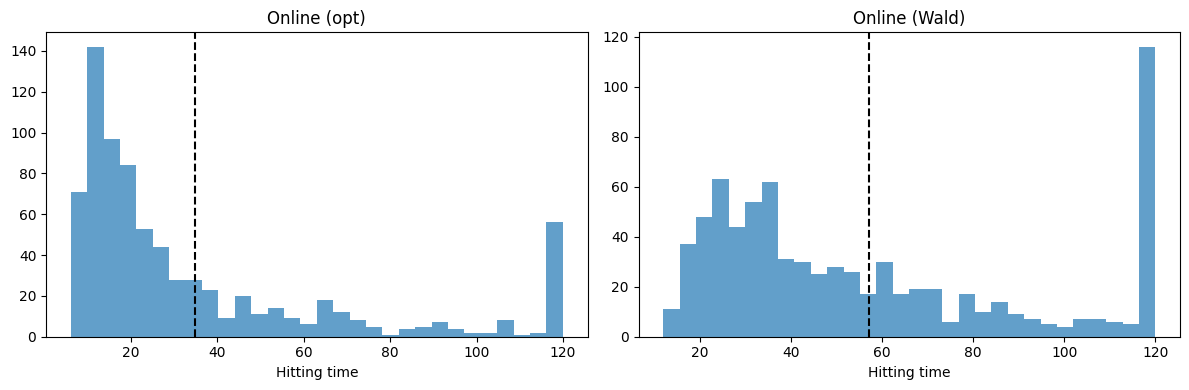

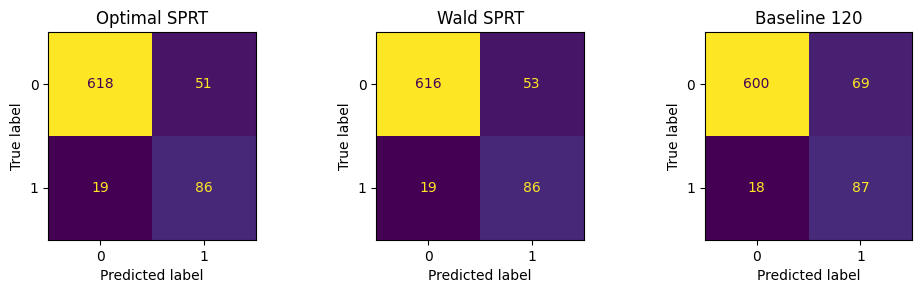

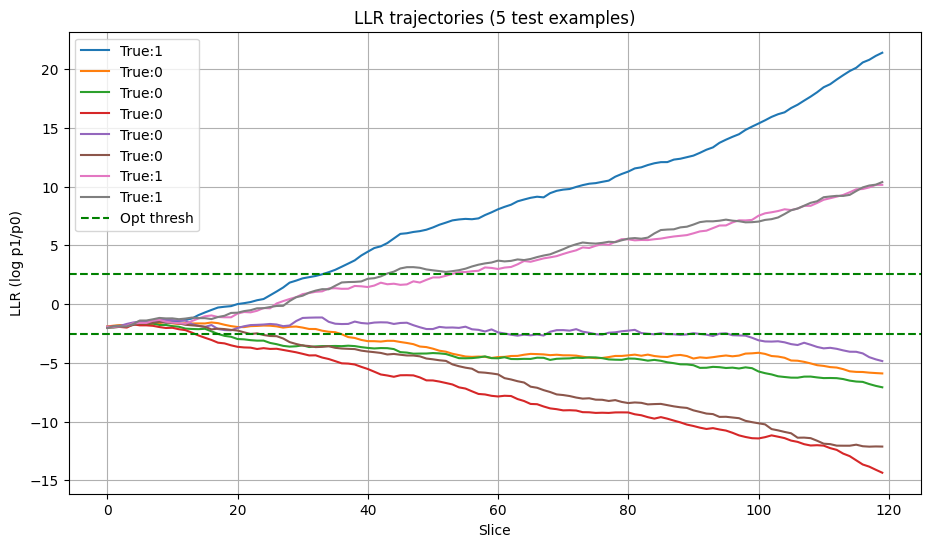

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(mhts_test, baccs_test, 'b-o', markersize=2, label='SPRT-TANDEM SAT')
for k, (bacc_k, _) in baseline_by_len.items():
    plt.scatter(k, bacc_k, color='orange', marker='X', s=80, zorder=5)
plt.scatter([120], [metrics_base['Bal.Acc']], color='r', marker='X', s=120, label='Baseline 120')
plt.scatter([metrics_opt['Mean HT']], [metrics_opt['Bal.Acc']],
            color='g', marker='D', s=120, label='Online opt')
plt.scatter([metrics_wald['Mean HT']], [metrics_wald['Bal.Acc']],
            color='m', marker='s', s=100, label='Online Wald')
plt.xlabel('Mean hitting time (slices)')
plt.ylabel('Balanced accuracy')
plt.title('Speed-Accuracy Trade-Off')
plt.legend(); plt.grid(True); plt.show()

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(hts_opt, bins=30, alpha=0.7, label='Optimal threshold')
axes[0].axvline(np.mean(hts_opt), color='k', linestyle='--')
axes[0].set_xlabel('Hitting time'); axes[0].set_title('Online (opt)')
axes[1].hist(hts_wald, bins=30, alpha=0.7, label='Wald threshold')
axes[1].axvline(np.mean(hts_wald), color='k', linestyle='--')
axes[1].set_xlabel('Hitting time'); axes[1].set_title('Online (Wald)')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1,3, figsize=(10,3))
ConfusionMatrixDisplay.from_predictions(y_test, preds_opt, ax=axes[0], colorbar=False)
axes[0].set_title('Optimal SPRT')
ConfusionMatrixDisplay.from_predictions(y_test, preds_wald, ax=axes[1], colorbar=False)
axes[1].set_title('Wald SPRT')
ConfusionMatrixDisplay.from_predictions(labs_base, preds_base, ax=axes[2], colorbar=False)
axes[2].set_title('Baseline 120')
plt.tight_layout(); plt.show()

test_llr_list = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        _, logits, _ = integrator(xb)
        llrs = calc_llrs(logits, ORDER, T, NUM_CLASSES)
        test_llr_list.append(llrs[:,:,1,0].cpu().numpy())
llr_all = np.concatenate(test_llr_list, axis=0)
plt.figure(figsize=(11,6))
for i in range(9, 17):
    plt.plot(range(T), llr_all[i], label=f"True:{y_test[i]}")
plt.axhline(y=a_opt, color='g', linestyle='--', label='Opt thresh')
plt.axhline(y=-a_opt, color='g', linestyle='--')
plt.xlabel('Slice'); plt.ylabel('LLR (log p1/p0)')
plt.title('LLR trajectories (5 test examples)')
plt.legend(); plt.grid(True); plt.show()